In [ ]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.special import erf
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ====================================================
# Loading SNe Ia data (Pantheon+SH0ES)
# ====================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"

df_sne       = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov      = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask     = df_sne["zCMB"].values > 0.01
df_cut   = df_sne[mask].reset_index(drop=True)
Cov_sne  = Cov_sne_full[mask, :][:, mask]
z_sne    = df_cut["zCMB"].values
mB_obs   = df_cut["m_b_corr"].values

Cinv_sne = np.linalg.inv(Cov_sne)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_MW_total  = DM_MW + 50.0      
DM_ext_obs   = DM_obs - DM_MW_total 

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Hard bounds
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
MB_min,       MB_max       = -19.8,  -18.6
sig_host_min, sig_host_max = 0.2,    2.0
e_mu_min,     e_mu_max     = 20.0,   200.0

# Gaussian priors
mu_Ob, sigma_Ob = 0.0495, 0.0025
mu_MB, sigma_MB = -19.24, 0.04

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical parameters
f_IGM = 0.83
chi_e = 0.875


# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)

In [4]:
# ===========================================================================
# Hubble functions
# ===========================================================================

def E_LCDM(z, Om0):
    Om = Om0 * (1 + z)**3
    Ol0 = 1 - Om0
    return np.sqrt(Om + Ol0)

def H_LCDM(z, H0, Om0):
    return H0 * E_LCDM(z, Om0)

In [5]:
# ========================================================
# Luminosity distance
# ========================================================

def dL_LCDM(z, H0, Om0):
    prefactor  = c_kms * (1.0 + z)
    H_grid     = H_LCDM(z_grid, H0, Om0)
    integrand  = 1.0 / H_grid
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z
    

# ========================================================
# Apparent magnitude
# ========================================================

def mB_LCDM(z, H0, Om0, MB):
    dL = dL_LCDM(z, H0, Om0)
    mu = 5.0 * np.log10(dL) + 25.0 
    return mu + MB


# ========================================================
# Quick test
# ========================================================

print("mB_LCDM(z_sne) =",
       mB_LCDM(z_sne, 72, 0.3, -19.24))

mB_LCDM(z_sne) = [13.9361052  13.98237464 13.98237464 ... 26.37710127 26.53576564
 26.98166657]


In [6]:
# ====================================================
# Theoretical IGM dispersion measure [pc/cm^3]
# ====================================================

def DM_IGM_LCDM(z, H0, Om0, Ob):
    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_grid    = H_LCDM(z_grid, H0, Om0)
    integrand = (1 + z_grid) / H_grid
    I_grid    = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, I_grid)
    DM_IGM_z    = prefactor * Ob * H0**2 * I_z                      # Before units conversion
    DM_IGM_corr = DM_IGM_z * (km_to_pc / (m2_to_cm2 * Mpc_to_cm))   # Physical units (pc cm^-3)
    return DM_IGM_corr


# ====================================================
# Quick test
# ====================================================

print("DM_IGM_LCDM(z_frb) =",
       DM_IGM_LCDM(z_frb, 70, 0.3, 0.0495))

DM_IGM_LCDM(z_frb) = [   7.21804968   16.18252862   20.19702758   25.45227641   25.83084621
   36.61304805   36.88285549   40.23159093   51.84554449   55.13341812
   55.48319192   56.79484363   60.39041606   61.54907941   61.70707896
   62.93596432   67.68593078   77.48412155   80.22696245   81.4693125
   85.10762334   91.33370829   93.78248801   93.91605781   95.78995662
   99.27449699  102.74329477  103.29907084  103.38871214  106.79508156
  106.92057939  110.56312807  111.01277268  113.08113786  113.7106403
  121.27766232  124.07417549  128.50617554  138.02426725  138.11502061
  139.23945481  141.56872747  156.52484867  162.6567792   169.90610648
  170.6409218   170.76052538  181.50589166  186.67321116  188.06011485
  190.83392224  204.27314438  208.91786108  211.24519307  214.03827587
  215.80443523  216.64515315  217.48454822  219.1640477   224.29585167
  224.48246272  235.52184233  243.49226912  248.56268594  250.53797361
  251.66670943  256.3412972   258.53795651  262.49590122  

In [ ]:
# ====================================================
# SNe + FRB likelihood
# ====================================================

# Log-prior
def lnprior_sne_frb(theta):
    H0, Om0, Ob, MB, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):       return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):      return -np.inf
    if not (0.0          <  Ob         <  Om0):          return -np.inf
    if not (MB_min       <= MB         <= MB_max):       return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max): return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):     return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    lp_MB = -0.5 * ((MB - mu_MB) / sigma_MB)**2
    return lp_Ob + lp_MB


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM,
                         sigma_host, exp_mu, npts=300):
    
    mu_host      = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)
    DM_hosp_grid = DM_hosp_grid[None, :]                        # (1, npts)
    DM_ext_array      = DM_ext_obs[:, None]                     # (N, 1)
    DM_IGM_array      = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None])
    sigma_IGM_array   = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    # standardized variable
    y = (DM_IGM_array - DM_IGM_mean_array) / sigma_IGM_array

    # standard normal PDF
    phi = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * y**2)

    # normalization factor: 1 - Φ(0 | μ, σ) = Φ(μ/σ)
    norm_factor = 0.5 * (1 + erf(DM_IGM_mean_array / (sigma_IGM_array * np.sqrt(2))))

    # truncated Gaussian
    P_IGM = (1 / sigma_IGM_array) * phi / norm_factor
    P_IGM[DM_IGM_array < 0] = 0.0

    # Host galaxy PDF (log-normal)
    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2 * np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host) / sigma_host)**2)
    
    # Convolution via numerical integration over DM_host
    integrand = P_IGM * P_host                                  # (N, npts)
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Joint likelihood
def lnlike_sne_frb(theta, z_sne, mB_obs, Cinv_sne, z_frb, DM_ext_obs):
    H0, Om0, Ob, MB, sigma_host, exp_mu = theta
    
    # --- SNe ---
    mB_model = mB_LCDM(z_sne, H0, Om0, MB)
    if not np.all(np.isfinite(mB_model)):
        return -np.inf
    resid_sne = mB_obs - mB_model
    lnL_sne   = -0.5 * (resid_sne @ Cinv_sne @ resid_sne)
    
    # --- FRB ---
    DM_IGM_mean = DM_IGM_LCDM(z_frb, H0, Om0, Ob)
    if not np.all(np.isfinite(DM_IGM_mean)):
        return -np.inf
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total   = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                     sigma_IGM, sigma_host, exp_mu)
    lnL_frb   = np.sum(np.log(P_total))
    return lnL_sne + lnL_frb


# Joint posterior
def lnprob_sne_frb(theta, z_sne, mB_obs, Cinv_sne, z_frb, DM_ext_obs):
    lp = lnprior_sne_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_sne_frb(theta, z_sne, mB_obs, Cinv_sne, z_frb, DM_ext_obs)


# ====================================================
# Quick test
# ====================================================

theta_test = [70.0, 0.3, 0.0495, -19.24, 0.7, 120.0]
print("SNe + FRB log-posterior =",
       lnprob_sne_frb(theta_test, z_sne, mB_obs, Cinv_sne, z_frb, DM_ext_obs))

SNe + FRB log-posterior = -1824.421447315667


In [8]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 6
nwalkers = 48
nsteps   = 30000

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_sne_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (SNe + FRB) ===")
t_mcmc = time.time()


sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_sne_frb,
    args=(z_sne, mB_obs, Cinv_sne, z_frb, DM_ext_obs)
)
sampler.run_mcmc(p0, nsteps, progress=True)

print(f"MCMC completed in {(time.time() - t_mcmc)/60:.1f} min")


=== Running MCMC (SNe + FRB) ===


100%|██████████| 30000/30000 [17:10<00:00, 29.12it/s]

MCMC completed in 17.2 min


In [9]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.513
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 71.84
Chain length / τ_max           = 417.6
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 215 steps (0.7%)
Thin (τ_max/2)                 = 35
Minimum N_eff                  = 19901
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [10]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log     = sampler.get_chain(discard=nburn, thin=nthin, flat=True)      # Apply thin
flat_log     = sampler.get_chain(discard=nburn, flat=True)                    # No thin
flat_samples = flat_log.copy()

fname = "flat_samples_LCDM_sne_frb.npy"
np.save(fname, flat_samples)
print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used              : {nburn} steps")
# print(f"Thin                      : {nthin}")
print(f"Saved to                  : {fname}")


Final independent samples : 1429680
Burn-in used              : 215 steps
Saved to                  : flat_samples_LCDM_sne_frb.npy


Removed no burn in


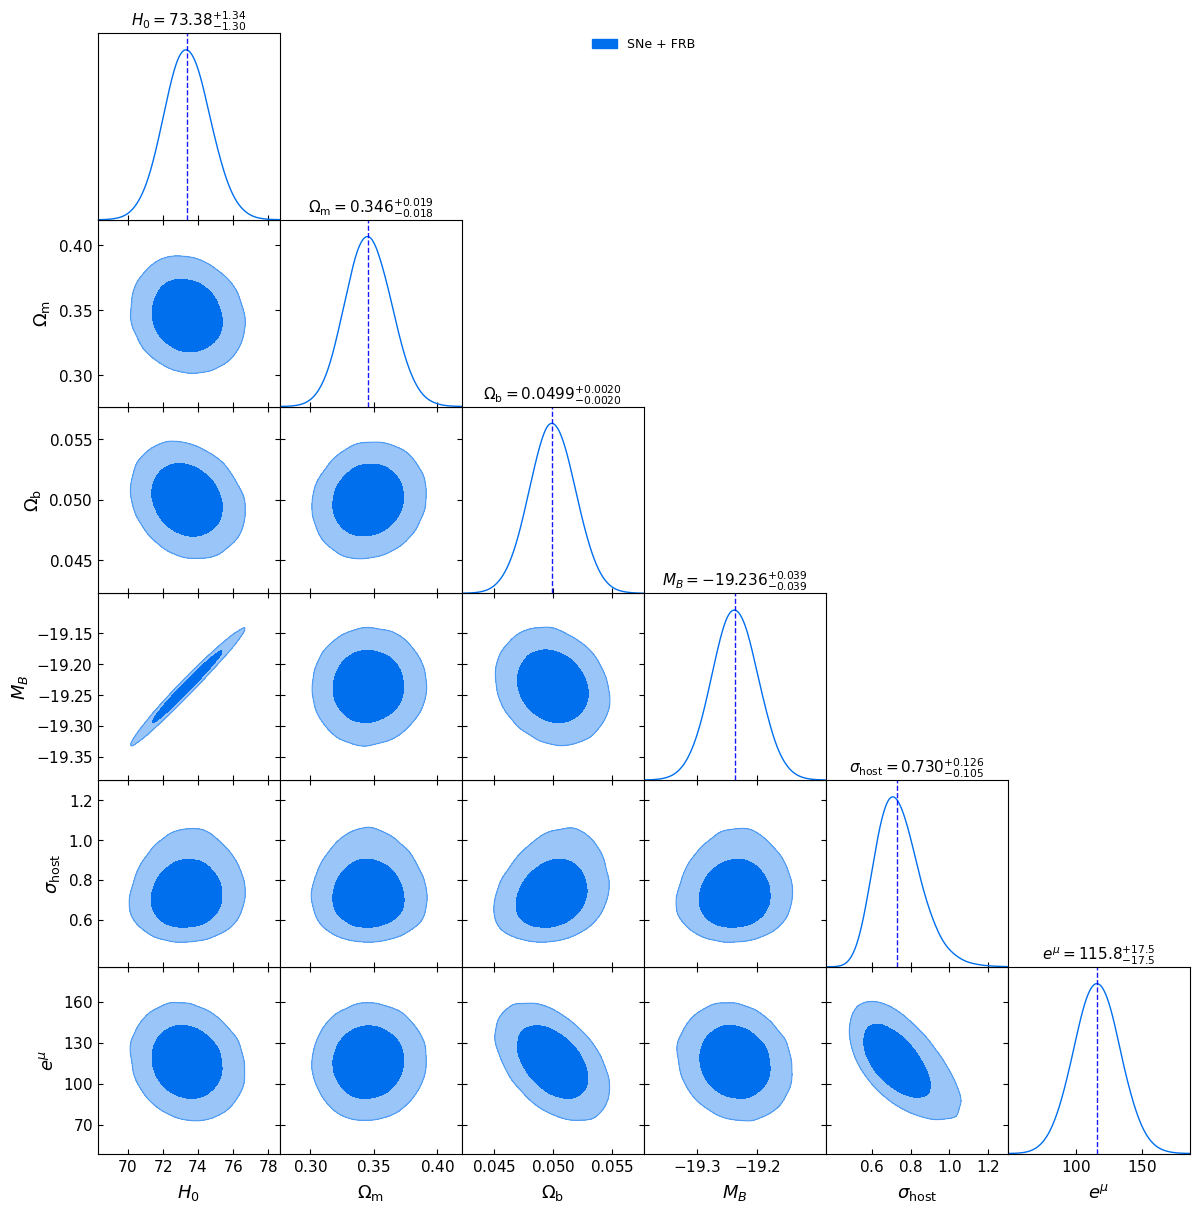

In [11]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}",
                r"M_B", r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=["SNe + FRB"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "sigma_host": ".3f", "exp_mu": ".1f"}

for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68

    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = "Corner_LCDM_sne_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("MB", 3), ("sigma_host", 4), ("exp_mu", 5)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "sigma_host": ".3f", "exp_mu": ".1f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (LCDM model | SNe + FRB data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")

print("\n" + "="*60)


   Final Inference Results (LCDM model | SNe + FRB data)    

  H0:
    73.38 +1.34 -1.30  (68% CL)
    73.38 +2.66 -2.56  (95% CL)

  Om0:
    0.346 +0.019 -0.018  (68% CL)
    0.346 +0.037 -0.035  (95% CL)

  Ob:
    0.0499 +0.0020 -0.0020  (68% CL)
    0.0499 +0.0039 -0.0039  (95% CL)

  MB:
    -19.236 +0.039 -0.039  (68% CL)
    -19.236 +0.077 -0.077  (95% CL)

  sigma_host:
    0.730 +0.126 -0.105  (68% CL)
    0.730 +0.274 -0.190  (95% CL)

  exp_mu:
    115.8 +17.5 -17.5  (68% CL)
    115.8 +34.9 -34.3  (95% CL)



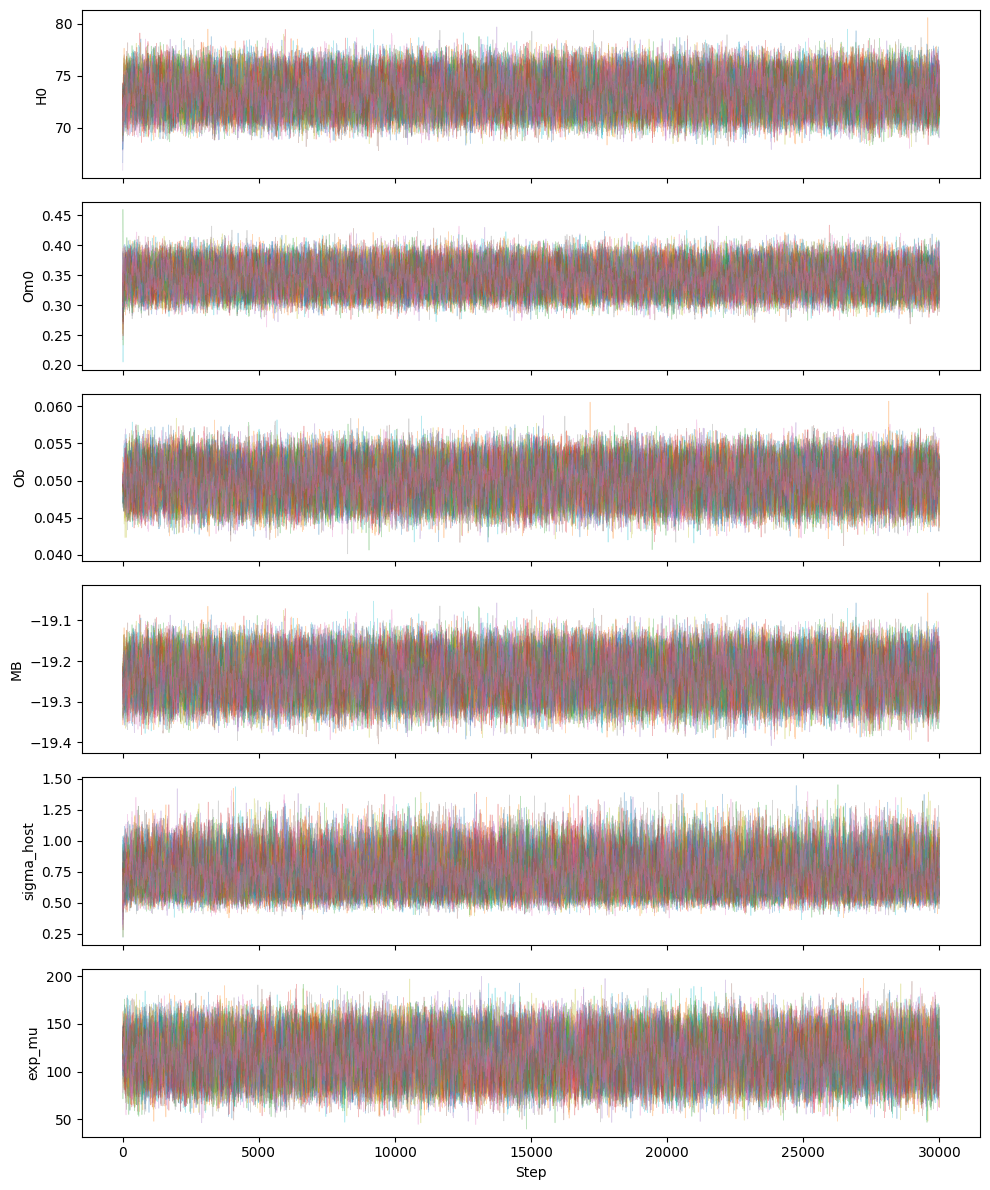

In [13]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(6, figsize=(10, 12), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()